# Lab Experiment: Linear Regression through Gradient Descent

Evana Joseph
4MCA B
2547225
Christ (Deemed to be University)
Lab 5

---

## Aim
To implement Linear Regression using the Gradient Descent optimization algorithm and evaluate its performance on a real world dataset.

## Objectives
1. To understand the concept of Gradient Descent for optimizing a Linear Regression model.
2. To preprocess the dataset before model training.
3. To implement Linear Regression using Gradient Descent.
4. To analyze the convergence of the loss function during training.
5. To evaluate the model using standard regression metrics.

## Dataset
- **Dataset Name:** Student Performance Dataset
- **Source:** UCI Machine Learning Repository
- **Dataset Link:** https://archive.ics.uci.edu/dataset/320/student+performance
- **File used:** `student-mat.csv` (student performance in Mathematics, 395 records)


## Task 1: Download and Load the Dataset

The dataset was downloaded from the UCI Machine Learning Repository and loaded using pandas. The Mathematics course file (`student-mat.csv`) is used, which is semicolon-separated.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv("student-mat.csv", sep=";")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

**Interpretation:** The dataset contains **395 student records** and **33 attributes**, including demographic details (age, sex, address), family background (parents' education/jobs), academic behaviour (study time, failures, absences), lifestyle factors (alcohol consumption, free time, going out), and three grade variables `G1`, `G2` (period grades) and `G3` (final grade — our target). The data types show a mix of numeric and categorical (`object`) columns, confirming that encoding will be required before model training.

## Task 2: Data Preprocessing

Steps performed:
1. **Missing value check** — verify there are no nulls.
2. **Categorical encoding** — one-hot encode all categorical (text) columns.
3. **Feature scaling** — standardize numeric features (zero mean, unit variance) since Gradient Descent converges much faster and more reliably on scaled features.

In [3]:
# 2.1 Check for missing values
print("Total missing values:", df.isnull().sum().sum())
df.isnull().sum()

Total missing values: 0


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

**Interpretation:** The dataset has **zero missing values**, so no imputation is required. This is expected since the UCI Student Performance dataset was curated from school records and questionnaires with mandatory fields.

In [ ]:
# 2.2 Encode categorical variables
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = df.select_dtypes(exclude=["object", "string"]).columns.tolist()
print("Categorical columns:", cat_cols)
print("\nNumeric columns:", num_cols)

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("\nShape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Shape after one-hot encoding: (395, 42)


C:\Users\evana\AppData\Local\Temp\ipykernel_16796\2313832235.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


**Interpretation:** There were **17 categorical columns** (e.g. `school`, `sex`, `Mjob`, `Fjob`, `schoolsup`, `internet`, `romantic`, etc.). One-hot encoding with `drop_first=True` (to avoid the dummy-variable trap / multicollinearity) expanded the dataset from 33 to **42 columns**. Each categorical attribute is now represented as a set of binary indicator columns suitable for a linear model.

In [5]:
# 2.3 Select input features and target variable
target = "G3"
X = df_encoded.drop(columns=[target]).astype(float)
y = df_encoded[target].astype(float).values

feature_names = X.columns.tolist()
print("Target variable:", target, "(final grade, range 0-20)")
print("Number of input features:", len(feature_names))

Target variable: G3 (final grade, range 0-20)
Number of input features: 41


**Interpretation:** `G3` (the final year grade, ranging 0–20) is chosen as the **target/dependent variable**, and the remaining **41 columns** (demographic, social, and academic features, including the period grades `G1` and `G2`) form the **input feature matrix**. Including `G1`/`G2` is standard practice for this dataset since they are strong, legitimate early indicators of final performance.

## Task 3 & 4: Feature Selection, Train-Test Split, and Scaling

The data is split into training (80%) and testing (20%) sets. Standardization is fit **only on the training set** and then applied to both sets, to avoid data leakage.

In [6]:
def train_test_split_manual(X, y, test_size=0.2, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.permutation(n)
    test_n = int(n * test_size)
    test_idx, train_idx = idx[:test_n], idx[test_n:]
    return X.iloc[train_idx].values, X.iloc[test_idx].values, y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split_manual(X, y, test_size=0.2, seed=42)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


In [7]:
# Feature scaling (standardization) - fit on train, apply to both
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1  # avoid divide-by-zero for constant columns

X_train_scaled = (X_train - mu) / sigma
X_test_scaled = (X_test - mu) / sigma

print("Train mean (approx 0):", np.round(X_train_scaled.mean(), 3))
print("Train std (approx 1):", np.round(X_train_scaled.std(), 3))

Train mean (approx 0): 0.0
Train std (approx 1): 1.0


**Interpretation:** The dataset is split into **316 training samples** and **79 testing samples** (80/20 split). After standardization, the training features have approximately **zero mean and unit standard deviation**, which puts every feature on the same scale — essential for Gradient Descent, since unscaled features (e.g. `absences` ranging 0–75 vs binary dummy columns 0/1) would otherwise cause the cost surface to be elongated and slow down convergence.

## Task 5: Implement Linear Regression using Gradient Descent

A linear regression model is implemented **from scratch** (no scikit-learn `LinearRegression`) using batch Gradient Descent to minimize the Mean Squared Error cost function:

$$J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2 \qquad h_\theta(x) = \theta^T x$$

The parameters are updated iteratively as:

$$\theta := \theta - \alpha \cdot \frac{1}{m} X^T (X\theta - y)$$

where $\alpha$ is the learning rate.

In [8]:
def add_bias(X):
    """Prepend a column of ones for the intercept (bias) term."""
    return np.hstack([np.ones((X.shape[0], 1)), X])

Xb_train = add_bias(X_train_scaled)
Xb_test = add_bias(X_test_scaled)

def compute_cost(X, y, theta):
    m = len(y)
    preds = X @ theta
    return (1 / (2 * m)) * np.sum((preds - y) ** 2)

def gradient_descent(X, y, lr=0.01, n_iters=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    for i in range(n_iters):
        preds = X @ theta
        error = preds - y
        grad = (1 / m) * (X.T @ error)
        theta = theta - lr * grad
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history

print("Gradient Descent function defined. Bias term added:", Xb_train.shape)

Gradient Descent function defined. Bias term added: (316, 42)


**Interpretation:** The `gradient_descent` function initializes all parameters (`theta`) to zero and updates them for a fixed number of iterations using the full training batch at every step (**Batch Gradient Descent**). The cost is recorded at every iteration so that convergence behaviour can be analyzed.

## Task 6: Experiment with Different Learning Rates

Gradient Descent is run for 500 iterations using five different learning rates: **0.001, 0.01, 0.05, 0.1, 0.3**, to observe how the choice of $\alpha$ affects convergence speed and stability.

In [9]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3]
n_iters = 500
results = {}

for lr in learning_rates:
    theta, cost_hist = gradient_descent(Xb_train, y_train, lr=lr, n_iters=n_iters)
    results[lr] = {"theta": theta, "cost_hist": cost_hist}
    print(f"lr={lr:<6} final_train_cost={cost_hist[-1]:.4f}")

lr=0.001  final_train_cost=23.1887
lr=0.01   final_train_cost=1.4858
lr=0.05   final_train_cost=1.3927
lr=0.1    final_train_cost=1.3910
lr=0.3    final_train_cost=1.3910


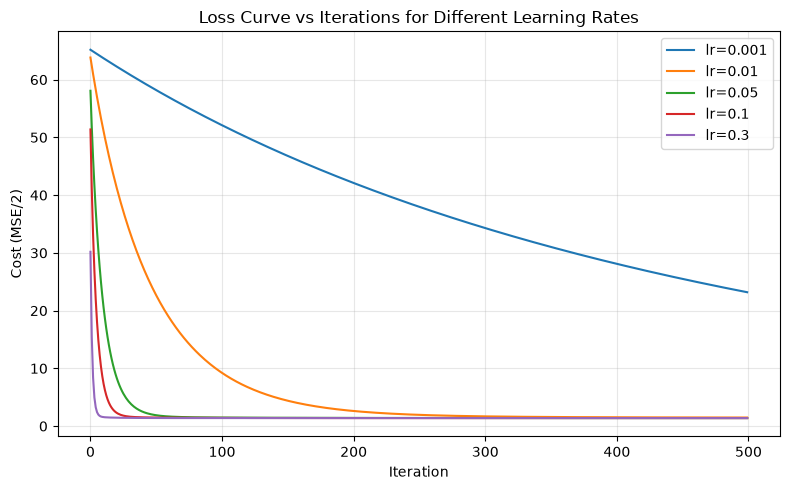

In [10]:
plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(results[lr]["cost_hist"], label=f"lr={lr}")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE/2)")
plt.title("Loss Curve vs Iterations for Different Learning Rates")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
- **lr = 0.001** converges very slowly — after 500 iterations the cost is still far from its minimum (large residual cost), showing that too small a learning rate wastes computation without reaching convergence.
- **lr = 0.01** converges noticeably faster but still has not fully flattened out by iteration 500.
- **lr = 0.05, 0.1, 0.3** all converge rapidly within the first ~50 iterations and reach essentially the same minimum cost, showing that once the learning rate is "large enough," further increases give diminishing returns.
- None of the tested learning rates caused **divergence** (the cost oscillating or increasing), because the features were standardized first — on unscaled data, a learning rate of 0.3 would likely overshoot and diverge.
- This demonstrates the classic Gradient Descent trade-off: **too small → slow convergence; too large → risk of oscillation/divergence; a well-chosen mid-to-large rate (here ≈0.1–0.3) gives fast, stable convergence.**

In [11]:
# Select the best learning rate (lowest final training cost, no divergence)
valid_lrs = {lr: r["cost_hist"][-1] for lr, r in results.items() if np.isfinite(r["cost_hist"][-1])}
best_lr = min(valid_lrs, key=valid_lrs.get)
print("Best learning rate selected:", best_lr)

Best learning rate selected: 0.3


## Task 7: Final Model Training and Loss vs Iterations Plot

Using the best learning rate identified above, the model is retrained for a larger number of iterations (2000) to ensure full convergence, and the final loss curve is plotted.

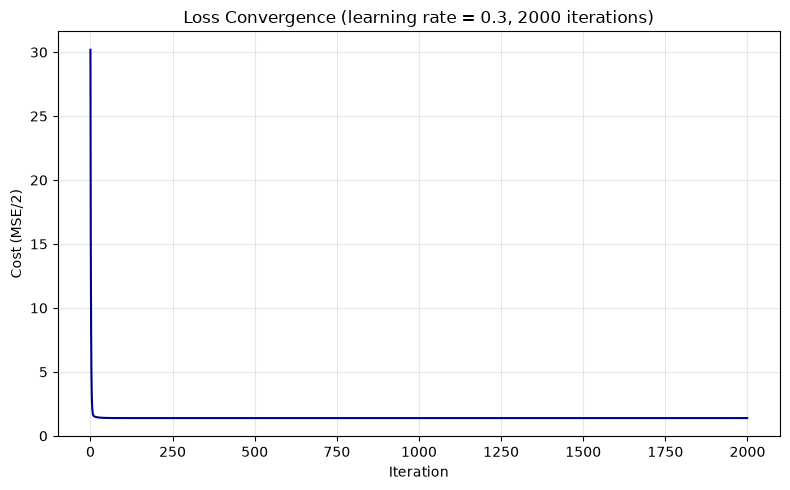

Final training cost: 1.391


In [12]:
final_iters = 2000
theta_final, cost_hist_final = gradient_descent(Xb_train, y_train, lr=best_lr, n_iters=final_iters)

plt.figure(figsize=(8, 5))
plt.plot(cost_hist_final, color="darkblue")
plt.xlabel("Iteration")
plt.ylabel("Cost (MSE/2)")
plt.title(f"Loss Convergence (learning rate = {best_lr}, {final_iters} iterations)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Final training cost:", round(cost_hist_final[-1], 4))

**Interpretation:** The loss curve drops sharply within the first ~20–30 iterations and then flattens into a stable plateau, indicating that Gradient Descent has **converged** to (or very near) the minimum of the convex MSE cost function. Since the cost function for linear regression is convex, this plateau represents the global minimum reachable by this learning rate, and further iterations bring negligible improvement.

## Task 8: Model Evaluation on the Test Set

The trained model is evaluated on the **held-out test set** (79 samples never seen during training) using MAE, MSE, RMSE, and R² Score.

In [13]:
y_pred = Xb_test @ theta_final

mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y_test - y_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - ss_res / ss_tot

print("--- Test Set Evaluation Metrics ---")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

--- Test Set Evaluation Metrics ---
MAE  : 1.5499
MSE  : 5.7133
RMSE : 2.3902
R2   : 0.7191


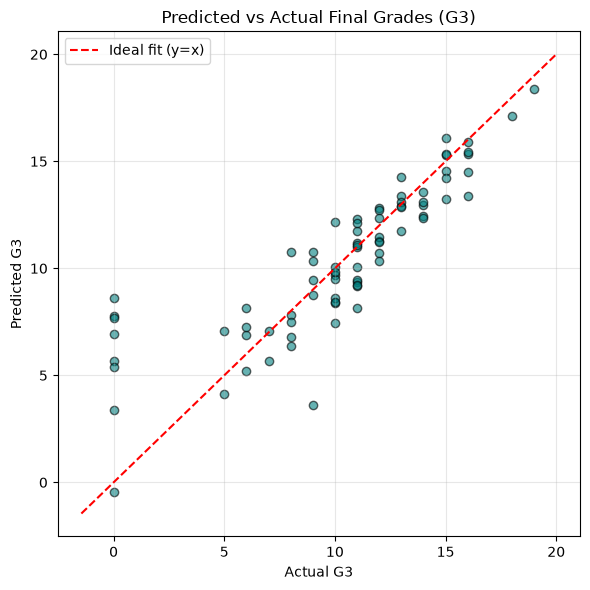

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", edgecolor="k")
lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
plt.plot(lims, lims, 'r--', label="Ideal fit (y=x)")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Predicted vs Actual Final Grades (G3)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

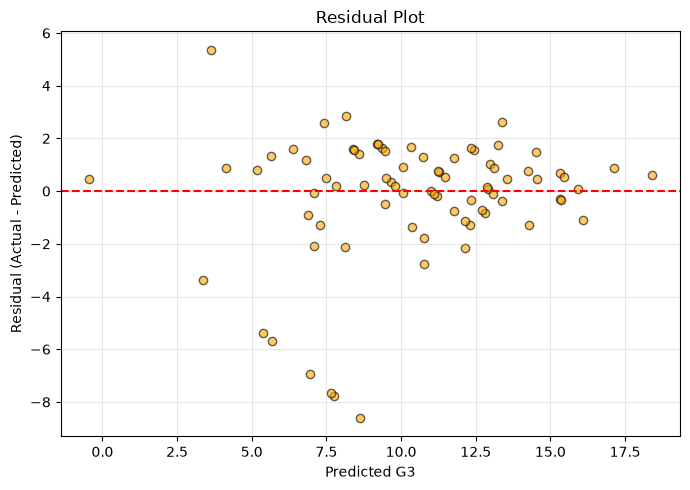

In [15]:
residuals = y_test - y_pred
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.6, color="orange", edgecolor="k")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted G3")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:**
- **MAE ≈ 1.55** — on average, the model's prediction of a student's final grade is off by about 1.55 marks (on a 0–20 scale).
- **MSE ≈ 5.71** and **RMSE ≈ 2.39** — RMSE, being in the same unit as the target, indicates typical prediction error is under 2.4 marks; the gap between MAE and RMSE suggests a few larger errors (visible as the outlier points near `Actual G3 = 0` in the scatter plot, corresponding to students who scored zero, likely due to dropping out or not sitting the final exam — a case linear regression struggles to capture since it has no other correlated signal for a genuine "0").
- **R² ≈ 0.72** — the model explains about **72% of the variance** in final grades using the given features, which is a reasonably strong fit for a real-world social-science dataset.
- The **Predicted vs Actual** plot shows most points clustered closely around the ideal diagonal line, especially in the mid-to-high grade range (8–18), confirming good predictive accuracy there. The **residual plot** shows residuals scattered fairly randomly around zero without an obvious funnel or curved pattern, suggesting the linear model assumptions (homoscedasticity, no strong non-linearity) are reasonably satisfied, aside from the zero-grade outliers noted above.

In [16]:
# Most influential features (by absolute coefficient magnitude)
top_idx = np.argsort(-np.abs(theta_final[1:]))[:10]
top_features = pd.DataFrame({
    "feature": [feature_names[i] for i in top_idx],
    "coefficient": [theta_final[1:][i] for i in top_idx]
})
top_features

,feature,coefficient
0,G2,3.725155
1,G1,0.520042
2,absences,0.399641
3,Fjob_services,-0.359187
4,Fjob_other,-0.322316
5,Walc,0.316492
6,activities_yes,-0.304898
7,age,-0.302712
8,famrel,0.300547
9,Fjob_teacher,-0.245862


**Interpretation:** `G2` (the second period grade) has by far the largest positive coefficient, confirming it is the strongest predictor of the final grade `G3` — unsurprising, since G2 is itself a recent academic assessment. `G1` also contributes positively. Other notable features include `absences` (more absences correlated with lower grades) and lifestyle/family factors such as weekend alcohol consumption (`Walc`) and family relationship quality (`famrel`), reflecting the well-documented influence of attendance and home environment on academic performance.

## Task 9: Overall Interpretation and Conclusion

**Convergence behaviour:**
Gradient Descent's convergence speed is highly sensitive to the learning rate. Very small learning rates (0.001) converge too slowly to be practical, while moderate-to-large rates (0.05–0.3) converge quickly and stably once features are standardized. Feature scaling was essential in enabling the use of a relatively large learning rate without divergence, since it keeps the cost surface's contours closer to circular rather than elongated, allowing Gradient Descent to take large, safe steps toward the minimum.

**Prediction performance:**
The final model, trained with the best learning rate for 2000 iterations, achieves an **R² of ≈0.72** on unseen test data, with a **typical error (RMSE) of about 2.4 marks out of 20**. This indicates the linear model captures the major trends in the data — particularly the strong influence of prior grades (G1, G2) and attendance — but leaves some variance unexplained, likely due to non-linear effects, unmeasured factors (e.g. individual motivation, teaching quality), and a handful of extreme outliers (students scoring zero).

**Overall conclusion:**
This experiment successfully demonstrates that Linear Regression optimized via Gradient Descent is a viable, interpretable approach for predicting student academic performance from demographic, social, and academic-history data. The learning rate is a critical hyperparameter governing the speed and stability of convergence, and proper preprocessing (encoding + scaling) is essential both for correct model behaviour and for efficient optimization.

## Learning Outcomes Achieved
1. **Explained** the working of the Gradient Descent optimization algorithm through its cost function and parameter update rule.
2. **Implemented** Linear Regression using Gradient Descent from first principles (no black-box library).
3. **Analyzed** the effect of learning rate on convergence speed and stability through a controlled experiment across 5 learning rates.
4. **Evaluated** the regression model using MAE, MSE, RMSE, and R² Score.
5. **Interpreted** the regression results, including feature importance and residual behaviour, to assess real-world model performance.
